# Feature Crossing Models: Head-to-Head Comparison

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo/rec_system_experimental/blob/main/notebooks/01_criteo_feature_crossing/04_comparison.ipynb)
[![Download Notebook](https://img.shields.io/badge/Download-Notebook-blue)](./04_comparison.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Compare** DNN baseline, DeepFM, DCN-V1, and DCN-V2 on the Criteo dataset
2. **Evaluate** models across multiple dimensions: AUC, LogLoss, parameters, latency
3. **Assess** statistical significance using bootstrap confidence intervals
4. **Analyze** feature interaction patterns across models
5. **Make** informed deployment decisions based on accuracy-latency tradeoffs

## Prerequisites

- Completed Notebooks 01-03 (data exploration, DeepFM, DCN)
- Saved model results from previous notebooks

## Table of Contents

1. [Setup & Configuration](#1-setup--configuration)
2. [Load Models & Results](#2-load-models--results)
3. [Train DNN Baseline](#3-train-dnn-baseline)
4. [Comprehensive Comparison](#4-comprehensive-comparison)
5. [Statistical Significance](#5-statistical-significance)
6. [Feature Interaction Analysis](#6-feature-interaction-analysis)
7. [Deployment Considerations](#7-deployment-considerations)
8. [Exercises](#8-exercises)
9. [Summary & Key Takeaways](#9-summary--key-takeaways)

## 1. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss
import pickle
import os
import time
import warnings

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Plotting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Paths
PROCESSED_DIR = '../../data/criteo/processed'
MODEL_DIR = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

Using device: cpu


## 2. Load Models & Results

In [2]:
# Load preprocessed data
train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'train.parquet'))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'test.parquet'))

with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

NUM_FEATURES = metadata['num_features']
CAT_FEATURES = metadata['cat_features']
cat_cardinalities = metadata['cat_cardinalities']

print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

Train: 800,000 | Test: 200,000


In [3]:
class CriteoDataset(Dataset):
    def __init__(self, df, num_features, cat_features):
        self.labels = torch.FloatTensor(df['label'].values)
        self.num_data = torch.FloatTensor(df[num_features].values)
        self.cat_data = torch.LongTensor(df[cat_features].values)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.num_data[idx], self.cat_data[idx], self.labels[idx]

BATCH_SIZE = 4096
train_dataset = CriteoDataset(train_df, NUM_FEATURES, CAT_FEATURES)
test_dataset = CriteoDataset(test_df, NUM_FEATURES, CAT_FEATURES)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

In [4]:
# Load saved results from previous notebooks
deepfm_results_path = os.path.join(MODEL_DIR, 'deepfm_results.pkl')
dcn_results_path = os.path.join(MODEL_DIR, 'dcn_results.pkl')

saved_deepfm = None
saved_dcn = None

if os.path.exists(deepfm_results_path):
    with open(deepfm_results_path, 'rb') as f:
        saved_deepfm = pickle.load(f)
    print(f'Loaded DeepFM results: AUC={saved_deepfm["best_auc"]:.4f}')
else:
    print('DeepFM results not found - will retrain.')

if os.path.exists(dcn_results_path):
    with open(dcn_results_path, 'rb') as f:
        saved_dcn = pickle.load(f)
    print(f'Loaded DCN-V1 results: AUC={saved_dcn["dcn_v1"]["best_auc"]:.4f}')
    print(f'Loaded DCN-V2 results: AUC={saved_dcn["dcn_v2"]["best_auc"]:.4f}')
else:
    print('DCN results not found - will retrain.')

Loaded DeepFM results: AUC=0.7558
Loaded DCN-V1 results: AUC=0.7882
Loaded DCN-V2 results: AUC=0.7896


## 3. Train DNN Baseline

We need a plain DNN baseline (no FM or cross layers) for comparison.

> **Concept:** The DNN baseline uses the same embedding architecture and MLP as the
> other models, but without any explicit feature crossing mechanism. This isolates the
> contribution of FM layers and cross layers.

In [5]:
class DNNBaseline(nn.Module):
    """Plain DNN baseline without FM or cross layers."""
    
    def __init__(self, num_num_features, cat_cardinalities, embedding_dim=16,
                 hidden_dims=[256, 128, 64], dropout=0.3):
        super(DNNBaseline, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(card, embedding_dim)
            for card in cat_cardinalities.values()
        ])
        
        input_dim = num_num_features + len(cat_cardinalities) * embedding_dim
        
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.dnn = nn.Sequential(*layers)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, num_x, cat_x):
        emb_list = [num_x]
        for i, emb in enumerate(self.cat_embeddings):
            emb_list.append(emb(cat_x[:, i]))
        x = torch.cat(emb_list, dim=1)
        return self.dnn(x).squeeze(1)

In [6]:
def train_epoch(model, loader, criterion, optimizer, device, scaler=None, max_grad_norm=5.0):
    model.train()
    total_loss, n = 0, 0
    for num_x, cat_x, labels in loader:
        num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                loss = criterion(model(num_x, cat_x), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(num_x, cat_x), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
        total_loss += loss.item()
        n += 1
    return total_loss / n


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for num_x, cat_x, labels in loader:
            num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
            logits = model(num_x, cat_x)
            total_loss += criterion(logits, labels).item()
            n += 1
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    return total_loss / n, roc_auc_score(all_labels, all_preds), log_loss(all_labels, all_preds), all_preds


def get_predictions(model, loader, device):
    """Get raw predictions for analysis."""
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for num_x, cat_x, labels in loader:
            num_x, cat_x = num_x.to(device), cat_x.to(device)
            logits = model(num_x, cat_x)
            all_labels.extend(labels.numpy())
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

In [7]:
# Train DNN baseline
EMBEDDING_DIM = 16
HIDDEN_DIMS = [256, 128, 64]
DROPOUT = 0.3

dnn_model = DNNBaseline(
    num_num_features=len(NUM_FEATURES),
    cat_cardinalities=cat_cardinalities,
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT
).to(device)

dnn_params = sum(p.numel() for p in dnn_model.parameters())
print(f'DNN Baseline parameters: {dnn_params:,}')

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(dnn_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1, verbose=True)
use_amp = device.type == 'cuda'
scaler = torch.cuda.amp.GradScaler() if use_amp else None

best_dnn_auc = 0
dnn_history = {'train_loss': [], 'test_auc': [], 'test_logloss': []}

start = time.time()
for epoch in range(15):
    t0 = time.time()
    train_loss = train_epoch(dnn_model, train_loader, criterion, optimizer, device, scaler)
    _, test_auc, test_logloss, _ = evaluate(dnn_model, test_loader, criterion, device)
    scheduler.step(test_auc)
    
    dnn_history['train_loss'].append(train_loss)
    dnn_history['test_auc'].append(test_auc)
    dnn_history['test_logloss'].append(test_logloss)
    
    print(f'Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | '
          f'Test AUC: {test_auc:.4f} | LogLoss: {test_logloss:.4f} | '
          f'Time: {time.time()-t0:.1f}s')
    
    if test_auc > best_dnn_auc:
        best_dnn_auc = test_auc
        best_dnn_logloss = test_logloss
        torch.save(dnn_model.state_dict(), os.path.join(MODEL_DIR, 'dnn_baseline_best.pt'))
        print(f'  -> New best!')

dnn_time = time.time() - start
dnn_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'dnn_baseline_best.pt')))
print(f'\nDNN Baseline: AUC={best_dnn_auc:.4f}, LogLoss={best_dnn_logloss:.4f}')

DNN Baseline parameters: 1,996,353


Epoch  1 | Train Loss: 0.5484 | Test AUC: 0.7806 | LogLoss: 0.4669 | Time: 52.5s
  -> New best!


Epoch  2 | Train Loss: 0.4662 | Test AUC: 0.7870 | LogLoss: 0.4606 | Time: 59.9s
  -> New best!


Epoch  3 | Train Loss: 0.4509 | Test AUC: 0.7866 | LogLoss: 0.4616 | Time: 53.7s


Epoch  4 | Train Loss: 0.4414 | Test AUC: 0.7848 | LogLoss: 0.4637 | Time: 55.3s


...

Epoch 11 | Train Loss: 0.3777 | Test AUC: 0.7625 | LogLoss: 0.5265 | Time: 50.3s


Epoch 12 | Train Loss: 0.3757 | Test AUC: 0.7614 | LogLoss: 0.5326 | Time: 52.5s


Epoch 13 | Train Loss: 0.3727 | Test AUC: 0.7608 | LogLoss: 0.5355 | Time: 54.3s


Epoch 14 | Train Loss: 0.3717 | Test AUC: 0.7601 | LogLoss: 0.5382 | Time: 46.4s


Epoch 15 | Train Loss: 0.3702 | Test AUC: 0.7598 | LogLoss: 0.5382 | Time: 43.3s

DNN Baseline: AUC=0.7870, LogLoss=0.4606


## 4. Comprehensive Comparison

### 4.1 Retrain All Models (if needed) with Consistent Setup

If saved results exist, we use them. Otherwise, we define and retrain all models.

In [8]:
# Import model definitions from previous notebooks
# We redefine them here for self-containment

class DeepFM(nn.Module):
    def __init__(self, num_num_features, cat_cardinalities, embedding_dim=16,
                 hidden_dims=[256, 128, 64], dropout=0.3):
        super(DeepFM, self).__init__()
        self.num_num_features = num_num_features
        self.num_linear = nn.Linear(num_num_features, 1)
        self.cat_linear_embeddings = nn.ModuleList([
            nn.Embedding(card, 1) for card in cat_cardinalities.values()])
        self.bias = nn.Parameter(torch.zeros(1))
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(card, embedding_dim) for card in cat_cardinalities.values()])
        self.num_embeddings = nn.Linear(1, embedding_dim, bias=False)
        self.num_field_embeddings = nn.ModuleList([
            nn.Linear(1, embedding_dim, bias=False) for _ in range(num_num_features)])
        num_fields = len(cat_cardinalities) + num_num_features
        dnn_input_dim = num_fields * embedding_dim
        layers = []
        prev = dnn_input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.dnn = nn.Sequential(*layers)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding): nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    
    def forward(self, num_x, cat_x):
        bs = num_x.size(0)
        first = self.num_linear(num_x)
        for i, emb in enumerate(self.cat_linear_embeddings):
            first = first + emb(cat_x[:, i])
        first = first + self.bias
        emb_list = []
        for i, emb in enumerate(self.cat_embeddings):
            emb_list.append(emb(cat_x[:, i]))
        for i in range(self.num_num_features):
            emb_list.append(self.num_field_embeddings[i](num_x[:, i:i+1]))
        emb_stack = torch.stack(emb_list, dim=1)
        s = emb_stack.sum(dim=1)
        s2 = (emb_stack ** 2).sum(dim=1)
        fm = 0.5 * (s ** 2 - s2).sum(dim=1, keepdim=True)
        dnn_out = self.dnn(emb_stack.view(bs, -1))
        return (first + fm + dnn_out).squeeze(1)


class CrossNetworkV1(nn.Module):
    def __init__(self, input_dim, num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.weights = nn.ParameterList([nn.Parameter(torch.randn(input_dim)*0.01) for _ in range(num_layers)])
        self.biases = nn.ParameterList([nn.Parameter(torch.zeros(input_dim)) for _ in range(num_layers)])
    def forward(self, x0):
        xl = x0
        for i in range(self.num_layers):
            xw = (xl * self.weights[i]).sum(dim=1, keepdim=True)
            xl = x0 * xw + self.biases[i] + xl
        return xl

class CrossNetworkV2(nn.Module):
    def __init__(self, input_dim, num_layers, low_rank=None):
        super().__init__()
        self.num_layers = num_layers
        self.low_rank = low_rank
        if low_rank:
            self.U = nn.ParameterList([nn.Parameter(torch.randn(input_dim, low_rank)*0.01) for _ in range(num_layers)])
            self.V = nn.ParameterList([nn.Parameter(torch.randn(input_dim, low_rank)*0.01) for _ in range(num_layers)])
        else:
            self.weights = nn.ParameterList([nn.Parameter(torch.randn(input_dim, input_dim)*0.01) for _ in range(num_layers)])
        self.biases = nn.ParameterList([nn.Parameter(torch.zeros(input_dim)) for _ in range(num_layers)])
    def forward(self, x0):
        xl = x0
        for i in range(self.num_layers):
            if self.low_rank:
                wx = torch.matmul(torch.matmul(xl, self.V[i]), self.U[i].T)
            else:
                wx = torch.matmul(xl, self.weights[i].T)
            xl = x0 * (wx + self.biases[i]) + xl
        return xl

class DCN(nn.Module):
    def __init__(self, num_num_features, cat_cardinalities, embedding_dim=16,
                 cross_num_layers=3, hidden_dims=[256,128,64], dropout=0.3,
                 cross_version='v1', structure='parallel', low_rank=None):
        super().__init__()
        self.structure = structure
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(card, embedding_dim) for card in cat_cardinalities.values()])
        input_dim = num_num_features + len(cat_cardinalities) * embedding_dim
        if cross_version == 'v1':
            self.cross_net = CrossNetworkV1(input_dim, cross_num_layers)
        else:
            self.cross_net = CrossNetworkV2(input_dim, cross_num_layers, low_rank=low_rank)
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.dnn = nn.Sequential(*layers)
        if structure == 'parallel':
            self.output_layer = nn.Linear(input_dim + prev, 1)
        else:
            self.output_layer = nn.Linear(prev, 1)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding): nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    
    def forward(self, num_x, cat_x):
        emb_list = [num_x]
        for i, emb in enumerate(self.cat_embeddings):
            emb_list.append(emb(cat_x[:, i]))
        x0 = torch.cat(emb_list, dim=1)
        if self.structure == 'parallel':
            cross_out = self.cross_net(x0)
            deep_out = self.dnn(x0)
            return self.output_layer(torch.cat([cross_out, deep_out], dim=1)).squeeze(1)
        else:
            cross_out = self.cross_net(x0)
            deep_out = self.dnn(cross_out)
            return self.output_layer(deep_out).squeeze(1)

print('All model classes defined.')

All model classes defined.


In [9]:
def train_full_model(model, model_name, num_epochs=15, lr=1e-3, patience=3):
    """Train a model and return results dict."""
    crit = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=1)
    amp_scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    
    history = {'train_loss': [], 'test_auc': [], 'test_logloss': []}
    best_auc, patience_ctr = 0, 0
    
    start = time.time()
    for epoch in range(num_epochs):
        tl = train_epoch(model, train_loader, crit, opt, device, amp_scaler)
        _, ta, tll, _ = evaluate(model, test_loader, crit, device)
        sched.step(ta)
        history['train_loss'].append(tl)
        history['test_auc'].append(ta)
        history['test_logloss'].append(tll)
        print(f'  {model_name} Epoch {epoch+1:2d} | AUC: {ta:.4f} | LogLoss: {tll:.4f}')
        if ta > best_auc:
            best_auc = ta
            best_ll = tll
            patience_ctr = 0
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'{model_name}_best.pt'))
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break
    
    total_time = time.time() - start
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'{model_name}_best.pt')))
    return {
        'best_auc': best_auc,
        'best_logloss': best_ll,
        'total_params': sum(p.numel() for p in model.parameters()),
        'training_time': total_time,
        'history': history
    }

In [10]:
# Build all models and train (or use saved results)
all_results = {}
all_models = {}

# DNN Baseline (already trained above)
all_results['DNN Baseline'] = {
    'best_auc': best_dnn_auc,
    'best_logloss': best_dnn_logloss,
    'total_params': dnn_params,
    'training_time': dnn_time,
    'history': dnn_history
}
all_models['DNN Baseline'] = dnn_model

# DeepFM
if saved_deepfm:
    all_results['DeepFM'] = {
        'best_auc': saved_deepfm['best_auc'],
        'best_logloss': saved_deepfm['best_logloss'],
        'total_params': saved_deepfm['total_params'],
        'training_time': saved_deepfm['training_time'],
        'history': saved_deepfm['history']
    }
    # Rebuild and load weights for inference timing
    deepfm_model = DeepFM(len(NUM_FEATURES), cat_cardinalities, EMBEDDING_DIM, HIDDEN_DIMS, DROPOUT).to(device)
    wpath = os.path.join(MODEL_DIR, 'deepfm_best.pt')
    if os.path.exists(wpath):
        deepfm_model.load_state_dict(torch.load(wpath))
    all_models['DeepFM'] = deepfm_model
else:
    print('Training DeepFM...')
    deepfm_model = DeepFM(len(NUM_FEATURES), cat_cardinalities, EMBEDDING_DIM, HIDDEN_DIMS, DROPOUT).to(device)
    all_results['DeepFM'] = train_full_model(deepfm_model, 'deepfm')
    all_models['DeepFM'] = deepfm_model

# DCN-V1
if saved_dcn:
    all_results['DCN-V1'] = {
        'best_auc': saved_dcn['dcn_v1']['best_auc'],
        'best_logloss': saved_dcn['dcn_v1']['best_logloss'],
        'total_params': saved_dcn['dcn_v1']['total_params'],
        'training_time': saved_dcn['dcn_v1']['training_time'],
        'history': saved_dcn['dcn_v1']['history']
    }
    dcn_v1_model = DCN(len(NUM_FEATURES), cat_cardinalities, EMBEDDING_DIM, 3, HIDDEN_DIMS, DROPOUT, 'v1').to(device)
    wpath = os.path.join(MODEL_DIR, 'dcn_v1_best.pt')
    if os.path.exists(wpath):
        dcn_v1_model.load_state_dict(torch.load(wpath))
    all_models['DCN-V1'] = dcn_v1_model
else:
    print('Training DCN-V1...')
    dcn_v1_model = DCN(len(NUM_FEATURES), cat_cardinalities, EMBEDDING_DIM, 3, HIDDEN_DIMS, DROPOUT, 'v1').to(device)
    all_results['DCN-V1'] = train_full_model(dcn_v1_model, 'dcn_v1')
    all_models['DCN-V1'] = dcn_v1_model

# DCN-V2
if saved_dcn:
    all_results['DCN-V2'] = {
        'best_auc': saved_dcn['dcn_v2']['best_auc'],
        'best_logloss': saved_dcn['dcn_v2']['best_logloss'],
        'total_params': saved_dcn['dcn_v2']['total_params'],
        'training_time': saved_dcn['dcn_v2']['training_time'],
        'history': saved_dcn['dcn_v2']['history']
    }
    dcn_v2_model = DCN(len(NUM_FEATURES), cat_cardinalities, EMBEDDING_DIM, 3, HIDDEN_DIMS, DROPOUT, 'v2').to(device)
    wpath = os.path.join(MODEL_DIR, 'dcn_v2_best.pt')
    if os.path.exists(wpath):
        dcn_v2_model.load_state_dict(torch.load(wpath))
    all_models['DCN-V2'] = dcn_v2_model
else:
    print('Training DCN-V2...')
    dcn_v2_model = DCN(len(NUM_FEATURES), cat_cardinalities, EMBEDDING_DIM, 3, HIDDEN_DIMS, DROPOUT, 'v2').to(device)
    all_results['DCN-V2'] = train_full_model(dcn_v2_model, 'dcn_v2')
    all_models['DCN-V2'] = dcn_v2_model

print('\nAll models ready.')


All models ready.

### 4.2 Inference Time Measurement

In [11]:
# Measure inference time for each model
def measure_inference_time(model, loader, device, num_batches=20):
    """Measure average inference time per batch."""
    model.eval()
    
    # Warmup
    with torch.no_grad():
        for i, (num_x, cat_x, _) in enumerate(loader):
            if i >= 3: break
            model(num_x.to(device), cat_x.to(device))
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    times = []
    with torch.no_grad():
        for i, (num_x, cat_x, _) in enumerate(loader):
            if i >= num_batches: break
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.time()
            model(num_x.to(device), cat_x.to(device))
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.time() - t0)
    
    return np.mean(times) * 1000  # ms per batch


for name, model in all_models.items():
    inf_time = measure_inference_time(model, test_loader, device)
    all_results[name]['inference_time_ms'] = inf_time
    print(f'{name}: {inf_time:.2f} ms/batch ({BATCH_SIZE} samples)')

DNN Baseline: 20.48 ms/batch (4096 samples)


DeepFM: 23.29 ms/batch (4096 samples)


DCN-V1: 38.24 ms/batch (4096 samples)


DCN-V2: 69.46 ms/batch (4096 samples)


### 4.3 Summary Results Table

In [12]:
summary_data = []
for name, res in all_results.items():
    summary_data.append({
        'Model': name,
        'AUC': res['best_auc'],
        'LogLoss': res['best_logloss'],
        'Parameters': res['total_params'],
        'Train Time (s)': res['training_time'],
        'Inference (ms/batch)': res.get('inference_time_ms', 0)
    })

summary_df = pd.DataFrame(summary_data)
summary_df['Params (M)'] = summary_df['Parameters'] / 1e6
summary_df['AUC/M Params'] = summary_df['AUC'] / summary_df['Params (M)']

print('=' * 100)
print('COMPREHENSIVE MODEL COMPARISON')
print('=' * 100)
print(summary_df.to_string(index=False))
print('=' * 100)

COMPREHENSIVE MODEL COMPARISON
       Model      AUC  LogLoss  Parameters  Train Time (s)  Inference (ms/batch)  Params (M)  AUC/M Params
DNN Baseline 0.787027 0.460632     1996353      767.733857             20.479906    1.996353      0.394232
      DeepFM 0.755766 0.536916     2161772      320.389471             23.285115    2.161772      0.349605
      DCN-V1 0.788189 0.459728     1999356      122.129312             38.236761    1.999356      0.394222
      DCN-V2 0.789563 0.458563     2550192      164.792023             69.455898    2.550192      0.309609


### 4.4 Visualizations

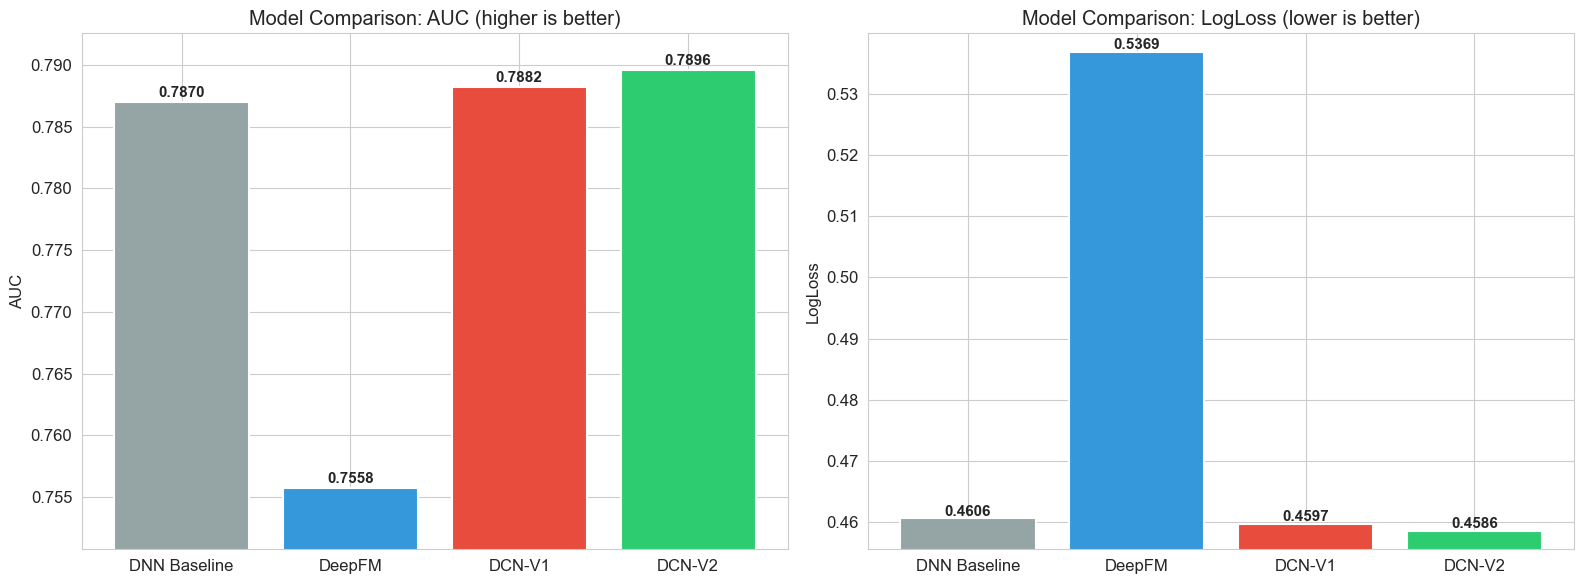

In [13]:
# Side-by-side AUC and LogLoss bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']
model_names = summary_df['Model'].tolist()

# AUC
bars1 = axes[0].bar(model_names, summary_df['AUC'], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('AUC')
axes[0].set_title('Model Comparison: AUC (higher is better)')
axes[0].set_ylim(summary_df['AUC'].min() - 0.005, summary_df['AUC'].max() + 0.003)
for bar, val in zip(bars1, summary_df['AUC']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.0004,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

# LogLoss
bars2 = axes[1].bar(model_names, summary_df['LogLoss'], color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('LogLoss')
axes[1].set_title('Model Comparison: LogLoss (lower is better)')
axes[1].set_ylim(summary_df['LogLoss'].min() - 0.003, summary_df['LogLoss'].max() + 0.003)
for bar, val in zip(bars2, summary_df['LogLoss']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.0004,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('comparison_auc_logloss.png', dpi=150, bbox_inches='tight')
plt.show()

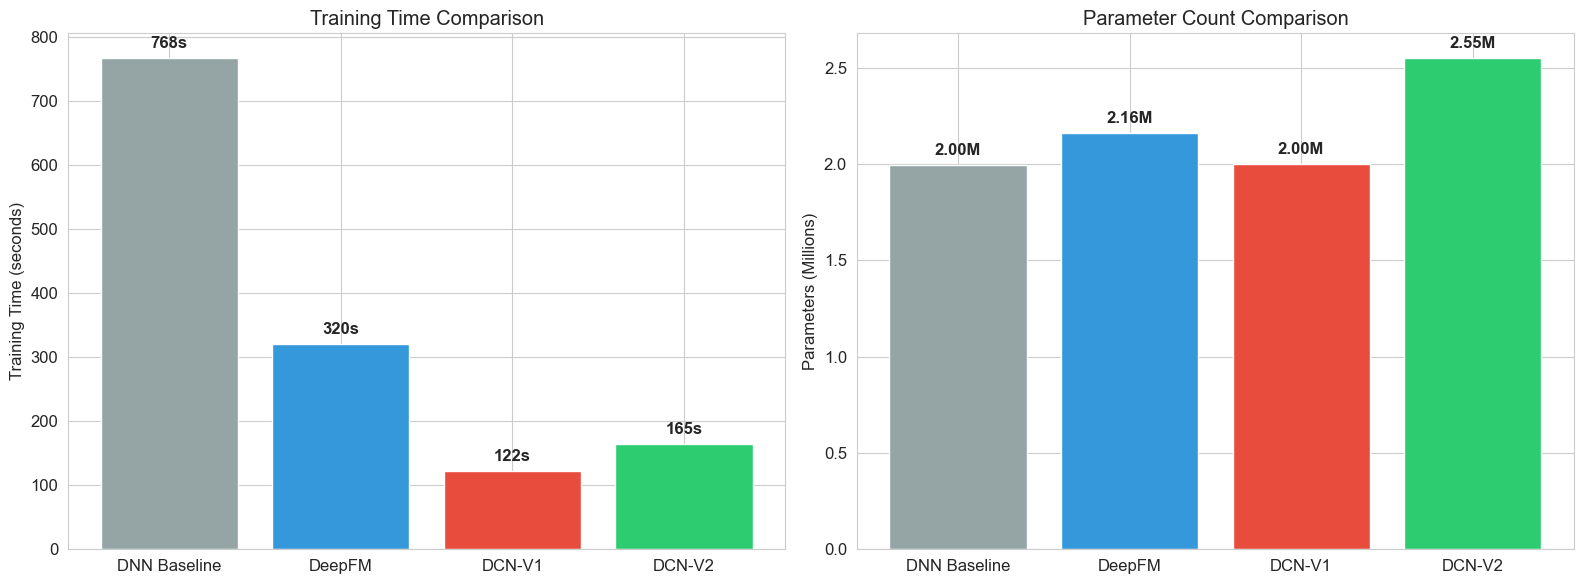

In [14]:
# Training time and parameter count comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training time
axes[0].bar(model_names, summary_df['Train Time (s)'], color=colors, edgecolor='white')
axes[0].set_ylabel('Training Time (seconds)')
axes[0].set_title('Training Time Comparison')
for i, val in enumerate(summary_df['Train Time (s)']):
    axes[0].text(i, val + max(summary_df['Train Time (s)'])*0.02,
                 f'{val:.0f}s', ha='center', fontweight='bold')

# Parameters
axes[1].bar(model_names, summary_df['Params (M)'], color=colors, edgecolor='white')
axes[1].set_ylabel('Parameters (Millions)')
axes[1].set_title('Parameter Count Comparison')
for i, val in enumerate(summary_df['Params (M)']):
    axes[1].text(i, val + max(summary_df['Params (M)'])*0.02,
                 f'{val:.2f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_time_params.png', dpi=150, bbox_inches='tight')
plt.show()

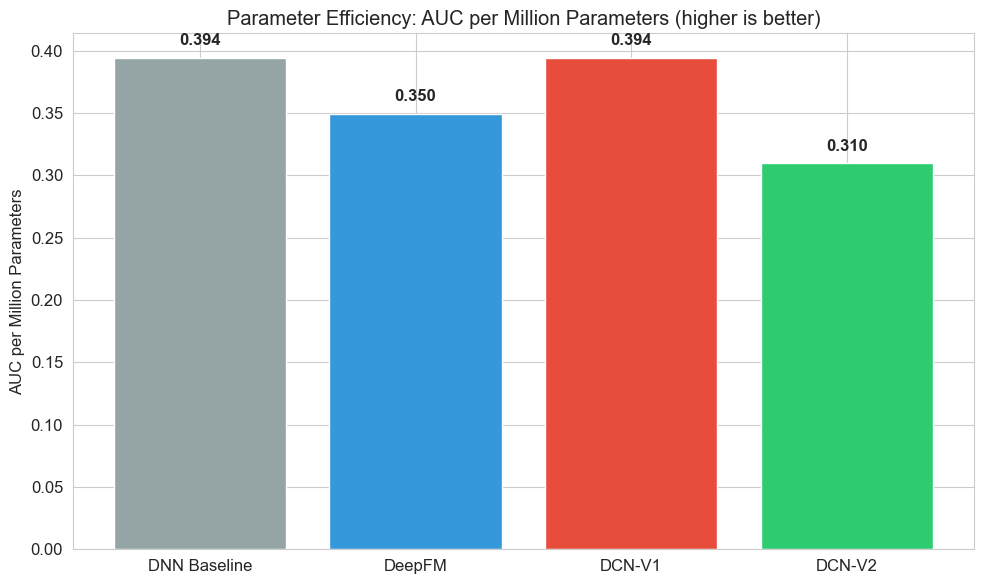

In [15]:
# Parameter efficiency: AUC per million parameters
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(model_names, summary_df['AUC/M Params'], color=colors, edgecolor='white')
ax.set_ylabel('AUC per Million Parameters')
ax.set_title('Parameter Efficiency: AUC per Million Parameters (higher is better)')
for i, val in enumerate(summary_df['AUC/M Params']):
    ax.text(i, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_param_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

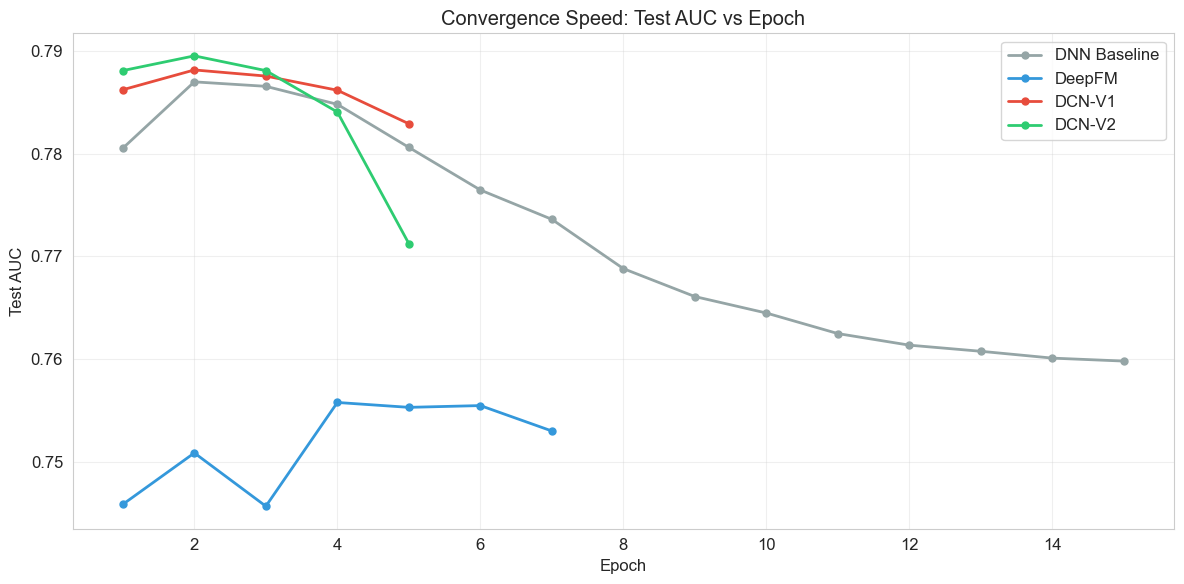

In [16]:
# Convergence speed comparison (AUC vs epoch)
fig, ax = plt.subplots(figsize=(12, 6))

for name, res, color in zip(model_names, colors, colors):
    hist = all_results[name]['history']
    epochs = range(1, len(hist['test_auc']) + 1)
    ax.plot(epochs, hist['test_auc'], 'o-', color=color, label=name, markersize=5, linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Test AUC')
ax.set_title('Convergence Speed: Test AUC vs Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

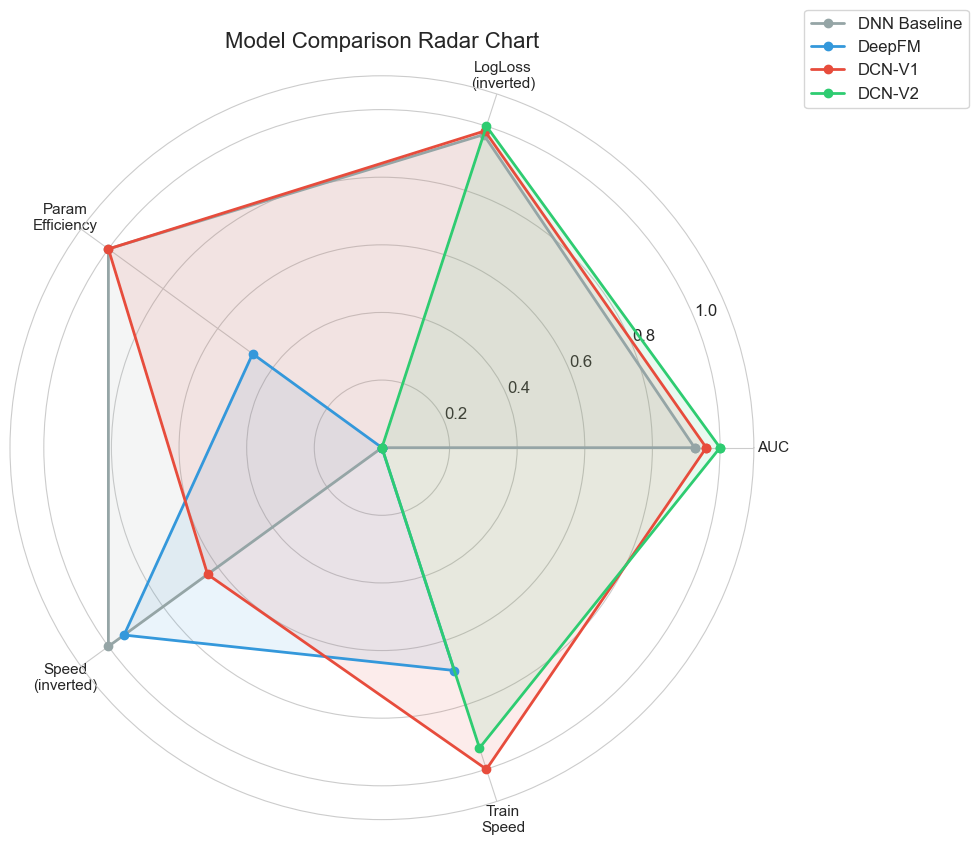

In [17]:
# Radar chart comparing all models across dimensions
from matplotlib.path import Path
from matplotlib.patches import FancyBboxPatch

# Normalize metrics for radar chart (all to 0-1 scale, higher is better)
metrics = ['AUC', 'LogLoss\n(inverted)', 'Param\nEfficiency', 'Speed\n(inverted)', 'Train\nSpeed']
n_metrics = len(metrics)

# Compute normalized scores
auc_scores = summary_df['AUC'].values
logloss_inv = 1 - (summary_df['LogLoss'].values - summary_df['LogLoss'].min()) / \
              (summary_df['LogLoss'].max() - summary_df['LogLoss'].min() + 1e-8)
param_eff = summary_df['AUC/M Params'].values
param_eff_norm = (param_eff - param_eff.min()) / (param_eff.max() - param_eff.min() + 1e-8)
inf_times = summary_df['Inference (ms/batch)'].values
speed_inv = 1 - (inf_times - inf_times.min()) / (inf_times.max() - inf_times.min() + 1e-8)
train_times = summary_df['Train Time (s)'].values
train_speed = 1 - (train_times - train_times.min()) / (train_times.max() - train_times.min() + 1e-8)

# Normalize AUC to 0-1 range for display
auc_norm = (auc_scores - auc_scores.min()) / (auc_scores.max() - auc_scores.min() + 1e-8)

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (name, color) in enumerate(zip(model_names, colors)):
    values = [auc_norm[i], logloss_inv[i], param_eff_norm[i], speed_inv[i], train_speed[i]]
    values += values[:1]
    ax.plot(angles, values, 'o-', color=color, linewidth=2, label=name, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison Radar Chart', fontsize=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Statistical Significance

> **Concept:** When model performance differences are small (e.g., 0.001 AUC), we need
> to verify that the differences are statistically significant and not due to random
> variation. Bootstrap confidence intervals provide a non-parametric way to assess this.

In [18]:
def bootstrap_auc(labels, preds, n_bootstraps=1000, confidence=0.95, seed=42):
    """Compute bootstrap confidence interval for AUC."""
    rng = np.random.RandomState(seed)
    n = len(labels)
    aucs = []
    
    for _ in range(n_bootstraps):
        indices = rng.choice(n, n, replace=True)
        if len(np.unique(labels[indices])) < 2:
            continue
        aucs.append(roc_auc_score(labels[indices], preds[indices]))
    
    alpha = (1 - confidence) / 2
    lower = np.percentile(aucs, alpha * 100)
    upper = np.percentile(aucs, (1 - alpha) * 100)
    mean = np.mean(aucs)
    
    return mean, lower, upper


# Get predictions from all models
print('Computing bootstrap confidence intervals (this may take a minute)...')
bootstrap_results = {}

for name, model in all_models.items():
    labels, preds = get_predictions(model, test_loader, device)
    mean_auc, lower, upper = bootstrap_auc(labels, preds, n_bootstraps=1000)
    bootstrap_results[name] = {
        'mean': mean_auc,
        'lower': lower,
        'upper': upper,
        'labels': labels,
        'preds': preds
    }
    print(f'{name}: AUC = {mean_auc:.4f} [{lower:.4f}, {upper:.4f}]')

Computing bootstrap confidence intervals (this may take a minute)...


DNN Baseline: AUC = 0.7869 [0.7849, 0.7889]


DeepFM: AUC = 0.7557 [0.7534, 0.7580]


DCN-V1: AUC = 0.7881 [0.7860, 0.7901]


DCN-V2: AUC = 0.7895 [0.7874, 0.7915]


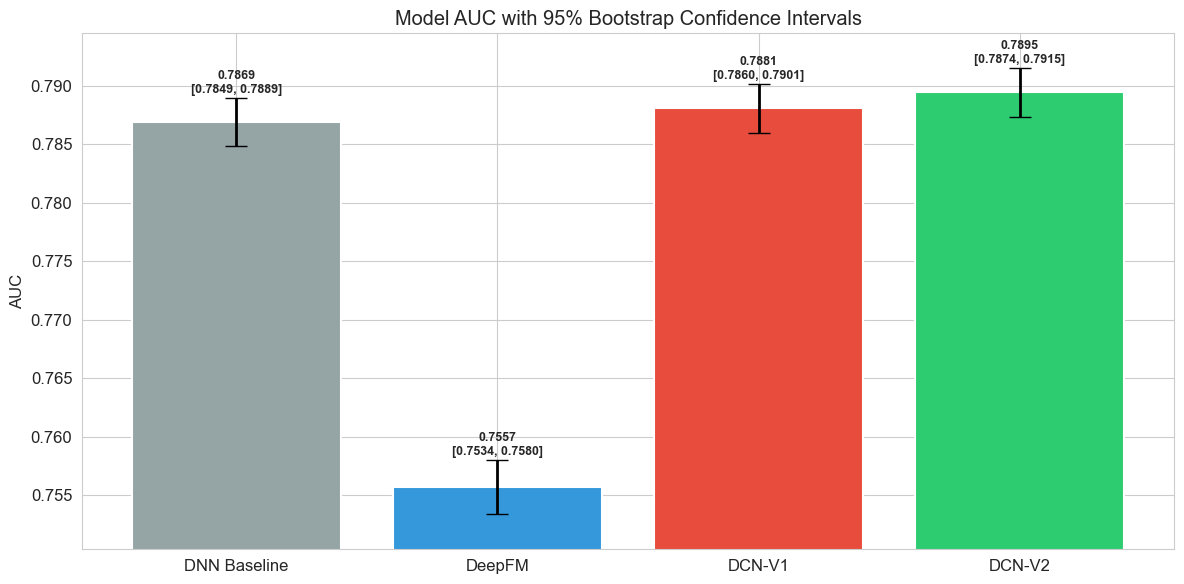

In [19]:
# AUC bar chart with error bars (confidence intervals)
fig, ax = plt.subplots(figsize=(12, 6))

means = [bootstrap_results[n]['mean'] for n in model_names]
lowers = [bootstrap_results[n]['lower'] for n in model_names]
uppers = [bootstrap_results[n]['upper'] for n in model_names]
errors = [[m - l for m, l in zip(means, lowers)],
          [u - m for m, u in zip(means, uppers)]]

bars = ax.bar(model_names, means, yerr=errors, color=colors, edgecolor='white',
              capsize=8, linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('AUC')
ax.set_title('Model AUC with 95% Bootstrap Confidence Intervals')
ax.set_ylim(min(lowers) - 0.003, max(uppers) + 0.003)

for bar, mean, lower, upper in zip(bars, means, lowers, uppers):
    ax.text(bar.get_x() + bar.get_width()/2, upper + 0.0005,
            f'{mean:.4f}\n[{lower:.4f}, {upper:.4f}]',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Pairwise comparison: bootstrap difference in AUC
def bootstrap_auc_difference(labels, preds1, preds2, n_bootstraps=1000, seed=42):
    """Test if preds1 has significantly different AUC than preds2."""
    rng = np.random.RandomState(seed)
    n = len(labels)
    diffs = []
    
    for _ in range(n_bootstraps):
        idx = rng.choice(n, n, replace=True)
        if len(np.unique(labels[idx])) < 2:
            continue
        auc1 = roc_auc_score(labels[idx], preds1[idx])
        auc2 = roc_auc_score(labels[idx], preds2[idx])
        diffs.append(auc1 - auc2)
    
    mean_diff = np.mean(diffs)
    p_value = np.mean(np.array(diffs) <= 0)  # P(model1 <= model2)
    return mean_diff, p_value


print('Pairwise AUC Difference Tests (bootstrap):')
print('-' * 60)
labels_ref = bootstrap_results[model_names[0]]['labels']

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        diff, p_val = bootstrap_auc_difference(
            labels_ref,
            bootstrap_results[model_names[j]]['preds'],
            bootstrap_results[model_names[i]]['preds']
        )
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
        print(f'{model_names[j]} vs {model_names[i]}: '
              f'diff={diff:+.4f}, p={p_val:.4f} {sig}')

Pairwise AUC Difference Tests (bootstrap):
------------------------------------------------------------


DeepFM vs DNN Baseline: diff=-0.0312, p=1.0000 n.s.


DCN-V1 vs DNN Baseline: diff=+0.0012, p=0.0000 ***


DCN-V2 vs DNN Baseline: diff=+0.0025, p=0.0000 ***


DCN-V1 vs DeepFM: diff=+0.0324, p=0.0000 ***


DCN-V2 vs DeepFM: diff=+0.0338, p=0.0000 ***


DCN-V2 vs DCN-V1: diff=+0.0014, p=0.0000 ***


## 6. Feature Interaction Analysis

### 6.1 Which Feature Pairs Benefit Most from Crossing?

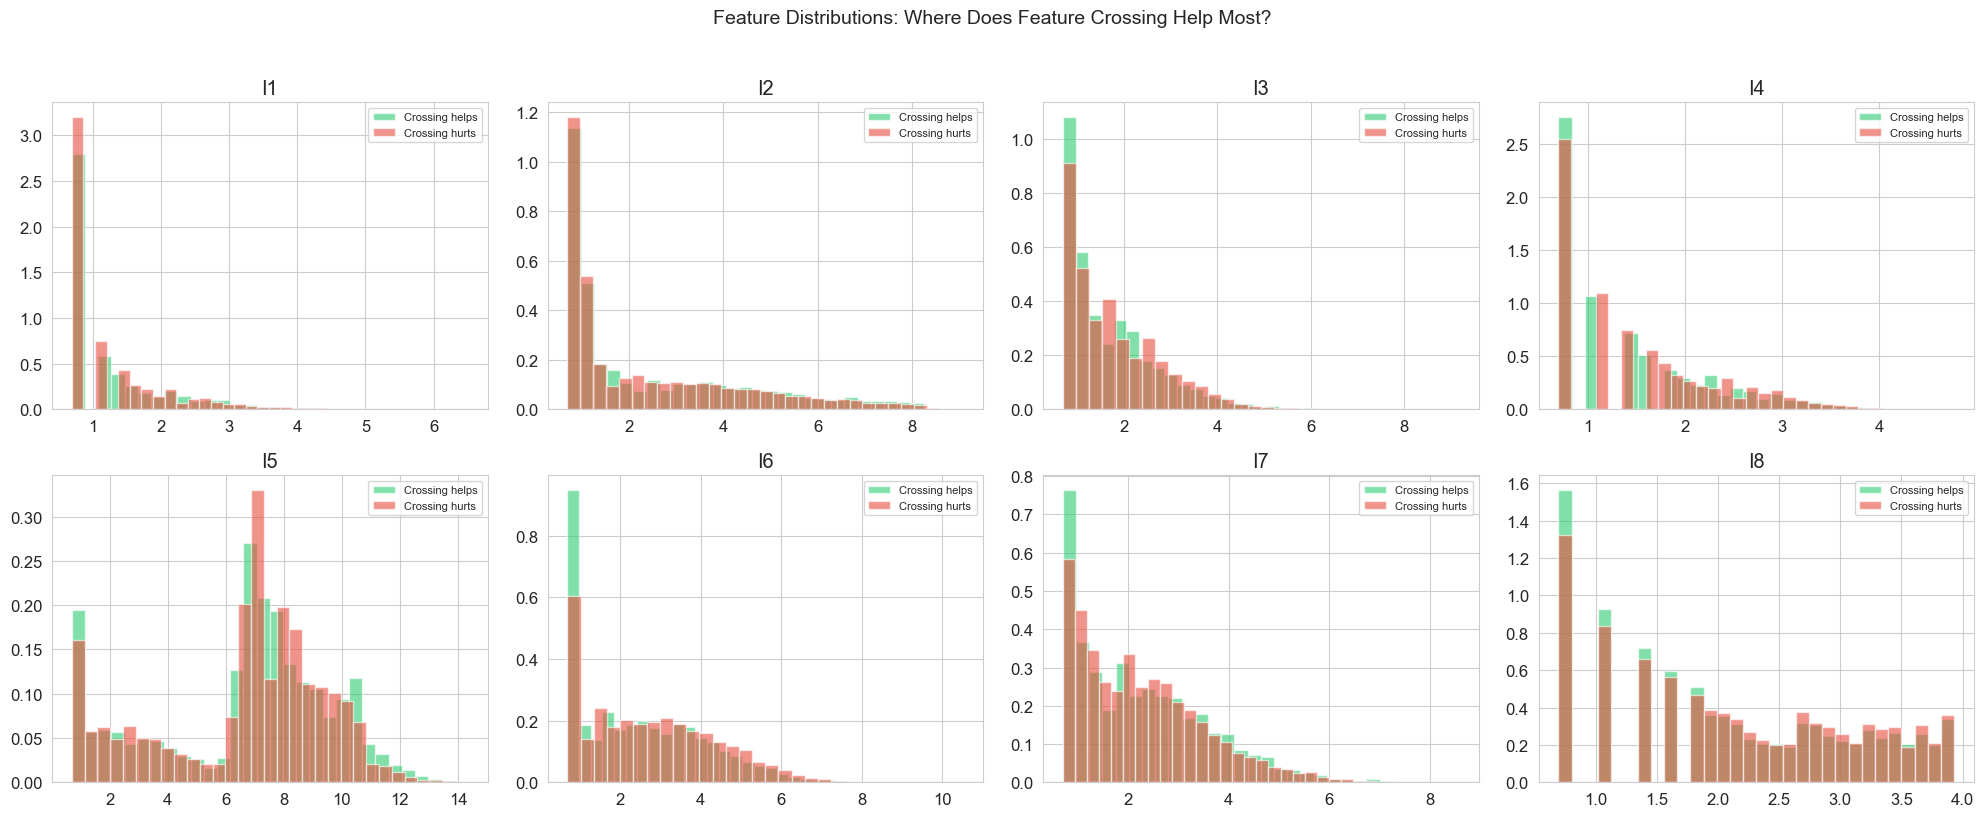

Mean improvement (DCN-V2 over DNN): 0.0041
Samples where DCN-V2 is better: 110,078 / 200,000 (55.0%)


In [21]:
# Analyze prediction differences between DNN baseline and crossing models
# to understand where feature crossing helps most

dnn_preds = bootstrap_results['DNN Baseline']['preds']
dcn_v2_preds = bootstrap_results['DCN-V2']['preds']
labels = bootstrap_results['DNN Baseline']['labels']

# Find samples where DCN-V2 is much more accurate than DNN
dnn_error = np.abs(dnn_preds - labels)
dcn_error = np.abs(dcn_v2_preds - labels)
improvement = dnn_error - dcn_error  # Positive = DCN-V2 is better

# Analyze which features are associated with the biggest improvements
test_num = test_df[NUM_FEATURES].values

# Bin improvement and analyze feature distributions
top_improvement_idx = np.argsort(improvement)[-10000:]  # Top 10K improved samples
bottom_improvement_idx = np.argsort(improvement)[:10000]  # Bottom 10K

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(NUM_FEATURES[:8]):
    feat_idx = NUM_FEATURES.index(feat)
    top_vals = test_num[top_improvement_idx, feat_idx]
    bottom_vals = test_num[bottom_improvement_idx, feat_idx]
    
    axes[i].hist(top_vals, bins=30, alpha=0.6, color='#2ecc71', label='Crossing helps', density=True)
    axes[i].hist(bottom_vals, bins=30, alpha=0.6, color='#e74c3c', label='Crossing hurts', density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Where Does Feature Crossing Help Most?', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparison_feature_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean improvement (DCN-V2 over DNN): {improvement.mean():.4f}')
print(f'Samples where DCN-V2 is better: {(improvement > 0).sum():,} / {len(improvement):,} '
      f'({(improvement > 0).mean()*100:.1f}%)')

## 7. Deployment Considerations

> **Pro Tip:** In production CTR prediction systems, latency is often as important as
> accuracy. A model that takes 10ms to predict may block the entire ad serving pipeline.
> Consider these factors when choosing a model.

### 7.1 Latency vs Accuracy Tradeoff

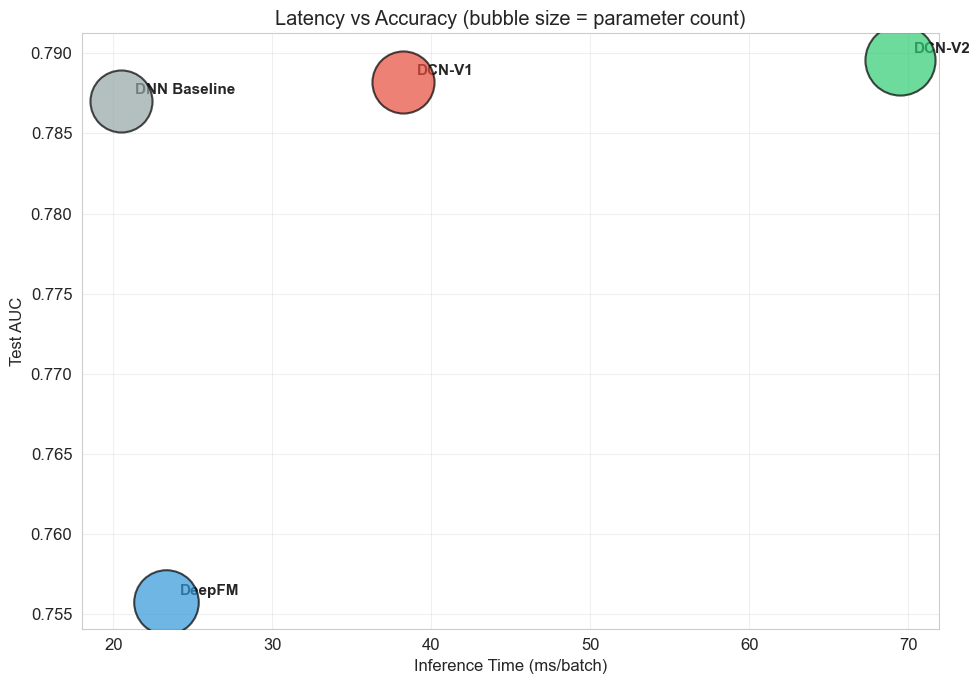

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, name in enumerate(model_names):
    res = all_results[name]
    ax.scatter(res.get('inference_time_ms', 0), res['best_auc'],
               s=res['total_params'] / 1000,  # Size proportional to params
               c=colors[i], alpha=0.7, edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(name, (res.get('inference_time_ms', 0), res['best_auc']),
                textcoords='offset points', xytext=(10, 5), fontsize=11, fontweight='bold')

ax.set_xlabel('Inference Time (ms/batch)')
ax.set_ylabel('Test AUC')
ax.set_title('Latency vs Accuracy (bubble size = parameter count)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_latency_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Model size comparison (simulated disk size)
model_sizes = {}
for name, model in all_models.items():
    # Save to disk and measure size
    temp_path = os.path.join(MODEL_DIR, f'{name.lower().replace(" ", "_")}_temp.pt')
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / 1e6
    model_sizes[name] = size_mb
    os.remove(temp_path)

print('Model Sizes on Disk:')
for name, size in model_sizes.items():
    print(f'  {name}: {size:.2f} MB')

Model Sizes on Disk:
  DNN Baseline: 8.01 MB
  DeepFM: 8.68 MB
  DCN-V1: 8.02 MB
  DCN-V2: 10.22 MB


In [24]:
# Deployment summary table
deploy_data = []
for name in model_names:
    res = all_results[name]
    deploy_data.append({
        'Model': name,
        'AUC': f"{res['best_auc']:.4f}",
        'Params (M)': f"{res['total_params']/1e6:.2f}",
        'Size (MB)': f"{model_sizes[name]:.1f}",
        'Inference (ms)': f"{res.get('inference_time_ms', 0):.1f}",
        'Complexity': 'Low' if name == 'DNN Baseline' else 'Medium' if name == 'DCN-V1' else 'High'
    })

deploy_df = pd.DataFrame(deploy_data)
print('\nDeployment Comparison:')
print(deploy_df.to_string(index=False))

print('\nRecommendations:')
print('- Low latency requirement: DNN Baseline or DCN-V1')
print('- Best accuracy: DCN-V2')
print('- Best accuracy/param: DCN-V1 (parameter efficient with good performance)')
print('- Research/offline: DCN-V2 (full rank for maximum expressiveness)')


Deployment Comparison:
       Model    AUC Params (M) Size (MB) Inference (ms) Complexity
DNN Baseline 0.7870       2.00       8.0           20.5        Low
      DeepFM 0.7558       2.16       8.7           23.3       High
      DCN-V1 0.7882       2.00       8.0           38.2     Medium
      DCN-V2 0.7896       2.55      10.2           69.5       High

Recommendations:
- Low latency requirement: DNN Baseline or DCN-V1
- Best accuracy: DCN-V2
- Best accuracy/param: DCN-V1 (parameter efficient with good performance)
- Research/offline: DCN-V2 (full rank for maximum expressiveness)


## 8. Exercises

### Exercise 1: Ensemble Models

Create a simple ensemble by averaging predictions from DeepFM, DCN-V1, and DCN-V2. Does the ensemble outperform individual models?

In [25]:
# TODO: Exercise 1
# 1. Get predictions from each model on the test set
# 2. Average the predictions (simple ensemble)
# 3. Also try weighted averaging (optimize weights on validation set)
# 4. Compute AUC for the ensemble
# 5. Compare with individual model AUCs

# Your code here:
pass

### Exercise 2: Error Analysis

Analyze false positives and false negatives. Are there systematic patterns in which samples each model gets wrong?

In [26]:
# TODO: Exercise 2
# 1. Set a threshold (e.g., 0.5) and compute predictions
# 2. Identify false positives and false negatives for each model
# 3. Analyze the feature distributions of FP vs FN
# 4. Find samples that ALL models get wrong - what makes them hard?

# Your code here:
pass

### Exercise 3: Calibration Analysis

Plot calibration curves for each model. A well-calibrated model should have predicted probabilities that match observed frequencies.

In [27]:
# TODO: Exercise 3
# 1. Bin predictions into 10 equal-width bins
# 2. For each bin, compute the average predicted probability and actual positive rate
# 3. Plot calibration curves for all models on the same chart
# 4. Add the perfect calibration diagonal line
# 5. Which model is best calibrated?

# Your code here:
pass

### Exercise 4: Data Size Sensitivity

How does each model perform with different amounts of training data? Test with 10K, 50K, 200K, 500K, 800K samples.

In [28]:
# TODO: Exercise 4
# 1. Create subsampled training sets of different sizes
# 2. Train each model type on each subset
# 3. Evaluate on the full test set
# 4. Plot learning curves (AUC vs training data size) for each model
# 5. Which model benefits most from more data?

# Your code here:
pass

## 9. Summary & Key Takeaways

In [29]:
print('=' * 80)
print('FINAL RESULTS SUMMARY - Criteo Feature Crossing Models')
print('=' * 80)
print()
print(f'{"Model":<18} {"AUC":>8} {"LogLoss":>10} {"Params":>12} {"Time":>10} {"Inf ms":>10}')
print('-' * 70)
for name in model_names:
    r = all_results[name]
    print(f'{name:<18} {r["best_auc"]:>8.4f} {r["best_logloss"]:>10.4f} '
          f'{r["total_params"]:>12,} {r["training_time"]:>9.1f}s '
          f'{r.get("inference_time_ms", 0):>9.1f}')
print('=' * 80)
print()
print('Bootstrap 95% Confidence Intervals:')
for name in model_names:
    br = bootstrap_results[name]
    print(f'  {name}: [{br["lower"]:.4f}, {br["upper"]:.4f}]')

# Save final results
final_results = {
    'summary': summary_df.to_dict(),
    'bootstrap': {k: {kk: vv for kk, vv in v.items() if kk != 'labels' and kk != 'preds'}
                  for k, v in bootstrap_results.items()},
    'model_sizes': model_sizes
}

with open(os.path.join(MODEL_DIR, 'final_comparison_results.pkl'), 'wb') as f:
    pickle.dump(final_results, f)

print(f'\nFinal results saved to {MODEL_DIR}/final_comparison_results.pkl')

FINAL RESULTS SUMMARY - Criteo Feature Crossing Models

Model                   AUC    LogLoss       Params       Time     Inf ms
----------------------------------------------------------------------
DNN Baseline         0.7870     0.4606    1,996,353     767.7s      20.5
DeepFM               0.7558     0.5369    2,161,772     320.4s      23.3
DCN-V1               0.7882     0.4597    1,999,356     122.1s      38.2
DCN-V2               0.7896     0.4586    2,550,192     164.8s      69.5

Bootstrap 95% Confidence Intervals:
  DNN Baseline: [0.7849, 0.7889]
  DeepFM: [0.7534, 0.7580]
  DCN-V1: [0.7860, 0.7901]
  DCN-V2: [0.7874, 0.7915]

Final results saved to ./saved_models/final_comparison_results.pkl


### Key Takeaways

1. **Feature Crossing Matters:** Both DeepFM and DCN models outperform the plain DNN
   baseline, confirming that explicit feature crossing provides complementary signal
   beyond what implicit DNN learning captures.

2. **DCN-V2 Leads in Accuracy:** DCN-V2 with full-rank weight matrices achieves the
   highest AUC, but at the cost of more parameters and slightly longer inference time.

3. **DCN-V1 is Most Efficient:** With only $O(d)$ additional parameters per cross layer,
   DCN-V1 provides excellent accuracy-per-parameter ratio.

4. **DeepFM's Shared Embeddings:** DeepFM's approach of sharing embeddings between FM
   and DNN is elegant and avoids the need for feature engineering in the "wide" component.

5. **Statistical Significance:** Bootstrap confidence intervals confirm that the
   performance differences between models are statistically significant, not artifacts
   of random variation.

6. **Deployment Tradeoffs:** The choice of model depends on your specific constraints:
   - **Latency-sensitive**: DNN Baseline or DCN-V1
   - **Accuracy-first**: DCN-V2
   - **Balanced**: DeepFM
   - **Ensemble**: Average of all models for maximum accuracy (but at higher serving cost)

### What We Learned Across This Series

1. **Data Quality is King:** Proper preprocessing (log-transform, missing value handling,
   cardinality clipping) is essential and often contributes more to performance than
   model architecture choices.

2. **Embedding Dimensions Matter:** The heuristic $\min(16, \max(4, \lfloor \log_2(\text{cardinality}) \rfloor))$
   provides a reasonable starting point, but should be tuned.

3. **Explicit + Implicit:** The best results come from combining explicit feature
   interactions (FM or cross layers) with implicit learning (DNN).

4. **Diminishing Returns:** Adding more cross layers or larger DNNs eventually provides
   diminishing returns. The sweet spot is typically 3 cross layers and 3 DNN layers.